In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, AllGaussianModels
from flax import nnx


ball_stick = AllGaussianModels.from_theta(np.random.randn(AllGaussianModels.theta_dim))

In [3]:
plt.style.use('../dmri/dmri/utils/pyloric_black.mplstyle')

Duplicate key in file '../dmri/dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [4]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(AllGaussianModels.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.5, shape=(len(AllGaussianModels.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(AllGaussianModels.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(AllGaussianModels.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    #model_mask = jnp.array([True, True, True])
    ball_stick = AllGaussianModels.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(bvals, bvecs, rng=rng5)
    return model_mask, theta, x_o, bvals, bvecs


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

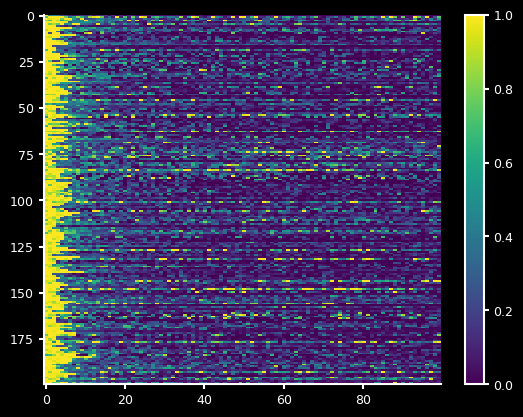

In [5]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [6]:
masks.shape, theta.shape, x_o.shape, bvals.shape, bvecs.shape

((200, 18), (200, 57), (200, 100), (200, 100), (200, 100, 3))

In [7]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig

cfg = DMRIInferenceModelConfig(AllGaussianModels)

model = DMRIInferenceModel(cfg, nnx.Rngs(1))

params = nnx.state(model, nnx.Param)


In [7]:
model(model_mask=masks, theta=theta, x=x_o, bvals=bvals, bvecs=bvecs)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)
y (200, 100, 64)
tokens_cfg (200, 19, 64)


(Array([[ 0.231, -0.77 ,  0.132, ..., -0.119, -0.099, -0.082],
        [ 0.264, -0.905, -0.65 , ...,  0.33 ,  0.335,  0.339],
        [ 0.406, -0.658, -0.515, ...,  0.705,  0.725,  1.3  ],
        ...,
        [ 0.292, -0.874, -0.673, ..., -0.174, -0.204, -0.23 ],
        [ 0.289, -0.726,  0.195, ...,  0.058,  0.347,  0.389],
        [ 0.072, -1.07 , -0.042, ..., -0.022, -0.004,  0.011]],      dtype=float32),
 Array([[-0.763, -1.428, -1.775, ..., -0.544, -1.613,  0.152],
        [ 0.66 ,  0.03 ,  0.17 , ..., -0.775, -0.596,  1.184],
        [-0.594,  0.391, -0.311, ..., -2.21 ,  1.329, -0.011],
        ...,
        [-0.783,  0.336, -0.634, ..., -0.718,  0.118, -0.643],
        [-0.066, -0.475, -0.031, ...,  0.01 ,  1.216,  1.306],
        [-2.793, -0.506, -1.217, ..., -0.505,  0.973,  1.237]],      dtype=float32))

In [8]:
nnx.display(model)

In [9]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [10]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data
    print(components.shape, thetas.shape, xs.shape, bvals.shape, bvecs.shape)
    return model.loss_fn(params,rng, components, thetas, xs, bvals,bvecs).sum()


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [44]:
key = jax.random.PRNGKey(12)
for i in range(100):
    key, subkey1 = jax.random.split(key, 2)
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**19))
    l = 0
    for j in range(1000):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (1024,), 0, 2**19)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/10000)

1.3654338
1.3653278
1.3649788
1.3662729
1.364643
1.3643924
1.3647835
1.3641912
1.3642769
1.363758
1.3636129
1.3636858
1.3649269
1.363072
1.3628286
1.3629524
1.3629777
1.3641487
1.3628777
1.362348
1.3647786


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155551a31510>>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


1.361896
1.3622706
1.3621558
1.3620796
1.3619624
1.3622622
1.3619207
1.3620012
1.3619964
1.3610609
1.3615587
1.3614796
1.3631103
1.3610246
1.3607951
1.3610954
1.3604473
1.3619701
1.3609456
1.3606855
1.3604152
1.3628081
1.3601505
1.3603944
1.359948
1.3617095
1.3600212
1.359751
1.360023
1.3597527
1.360128
1.3604017
1.3608105
1.3603914
1.3593884
1.3598386
1.3593669
1.360594
1.3592666
1.3594843
1.3590813
1.3593699
1.3615903
1.3594562
1.3590813
1.3590417
1.3599027
1.3592855
1.3588011
1.3586837
1.3600155
1.3584561
1.3587401
1.3586823
1.3583424
1.3584375
1.3583738
1.3579634
1.3599893
1.3584802
1.3578329
1.3580794
1.359856
1.3579332
1.3580917
1.3577332
1.357992
1.3574202
1.3593596
1.3576323
1.3580275
1.357703
1.3575518
1.3585144
1.357569
1.3580012
1.3578887
1.3574096
1.3572509


In [10]:
nnx.update(model, params)

In [46]:
# import pickle

# with open('params_large.pkl', 'wb') as f:
#     pickle.dump(params, f)

In [9]:
import pickle
with open('params_large.pkl', 'rb') as f:
    params = pickle.load(f)

In [16]:
idx = 10
masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 2000))
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx])

In [47]:
jax.clear_caches()

In [11]:
from dmri.utils.eval import run_tarp

_sample_mask_batched =jax.vmap(model.sample_mask, in_axes=(None,0,0, 0))
_sample_mask_batched_batched = jax.jit(jax.vmap(_sample_mask_batched, in_axes=(0,None,None, None)))


true_masks = []
posterior_masks = []
for i in range(10):
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(i), 2000))
    masks_per_obs = _sample_mask_batched_batched(jax.random.split(jax.random.key(i+10), 256), bvals, bevecs, x_os)
    true_masks.append(masks)
    posterior_masks.append(masks_per_obs)


(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)


In [12]:
true_masks = jnp.concatenate(true_masks, axis=0)
posterior_masks = jnp.concatenate(posterior_masks, axis=1)

#print(ture_masks.shape, posterior_masks.shape)
ecd, alpha = run_tarp(true_masks.astype(jnp.float32), posterior_masks.astype(jnp.float32), num_bins=50)

(256, 20000) (20000,)


Text(0, 0.5, 'Empirical coverage')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

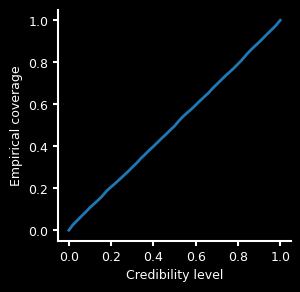

In [13]:
fig = plt.figure(figsize=(3, 3))
plt.plot(alpha,ecd, lw=2)
plt.xlabel('Credibility level')
plt.ylabel('Empirical coverage')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

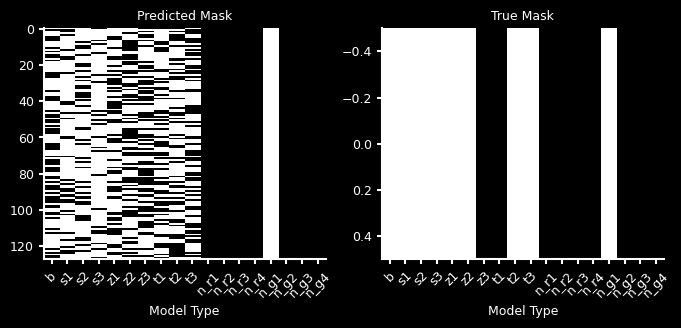

In [19]:
plt.figure(figsize=(8, 3))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianModels.model_types) + len(AllGaussianModels.noise_types)), ["b", "s1","s2", "s3", "z1", "z2", "z3", "t1", "t2", "t3", "n_r1", "n_r2","n_r3", "n_r4", "n_g1", "n_g2","n_g3", "n_g4"], rotation=45)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianModels.model_types) + len(AllGaussianModels.noise_types)), ["b", "s1","s2", "s3", "z1", "z2", "z3", "t1", "t2", "t3", "n_r1", "n_r2","n_r3", "n_r4", "n_g1", "n_g2","n_g3", "n_g4"], rotation=45)

plt.show()

In [21]:
from functools import partial

In [22]:
from dmri.utils.eval import run_tarp

_sample_theta_batched =jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=40), in_axes=(None,0,0, 0,0))
_sample_theta_batched_batched = jax.jit(jax.vmap(_sample_theta_batched, in_axes=(0,None,None, None, None)))

thetas_per_obs = _sample_theta_batched_batched(jax.random.split(jax.random.key(0), 128), bvals, bevecs, x_os, masks)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)


In [23]:

true_thetas = []
posterior_thetas = []
for i in range(20):
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(i), 1000))
    thetas_per_obs = _sample_theta_batched_batched(jax.random.split(jax.random.key(i+10), 256), bvals, bevecs, x_os, masks)
    true_thetas.append(thetas)
    posterior_thetas.append(thetas_per_obs)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)


In [25]:
true_thetas = jnp.concatenate(true_thetas, axis=0)
posterior_thetas = jnp.concatenate(posterior_thetas, axis=1)

In [28]:

#print(ture_masks.shape, posterior_masks.shape)
ecd, alpha = run_tarp(true_thetas.astype(jnp.float32), posterior_thetas.astype(jnp.float32), num_bins=50)

(256, 20000) (20000,)


Text(0, 0.5, 'Empirical coverage')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

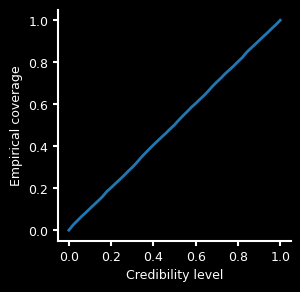

In [29]:
fig = plt.figure(figsize=(3, 3))
plt.plot(alpha,ecd, lw=2)
plt.xlabel('Credibility level')
plt.ylabel('Empirical coverage')

In [30]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), bvals[idx], bevecs[idx], x_os[idx],mask[idx])

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)


In [ ]:
# import sbi
# from sbi.analysis.plot import pairplot

# _ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

: 

In [41]:
idx = 10
masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 2000))
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx])

thetas_post = jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx],mask[idx])

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17)


In [42]:
def posterior_pred(theta,rng):
    return AllGaussianModels.from_theta(theta, model_mask=mask[idx]).signal(bvals[idx], bevecs[idx], rng=rng)

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 128))

In [48]:
mean = posterior_preds.mean(axis=0)
quantile_low = jnp.quantile(posterior_preds, 0.05, axis=0)
quantile_high = jnp.quantile(posterior_preds, 0.95, axis=0)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

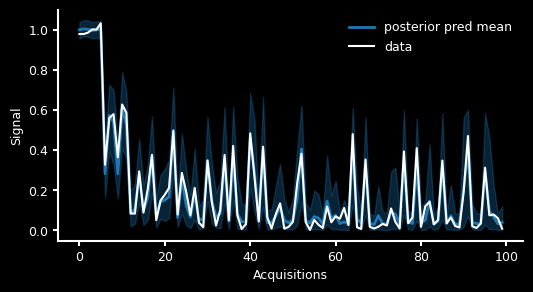

In [53]:
fig = plt.figure(figsize=(6, 3))
_ = plt.plot(mean, label="posterior pred mean", color="C0", linewidth=2)
_ = plt.fill_between(range(len(mean)), quantile_low, quantile_high, alpha=0.3, color="C0")
_ = plt.plot(x_os[idx], label="data", color="white")

plt.xlabel("Acquisitions")
plt.ylabel("Signal")

plt.legend()
